### Weekday Mini Drill
Gavin Qu 11-28-2025

#### 1. Load the Dataset

In [ ]:
from sklearn import datasets
import pandas as pd
import numpy as np

iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

In [29]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


#### 2. Inject Missingness

In [30]:
# choose a col
missing = ["sepal width (cm)", "petal length (cm)", "sepal length (cm)"]
idx = np.random.choice(df.index, size=15, replace=False)
df.loc[idx, missing] = np.nan

print(f"missing value sum: {df.isna().sum()}")

missing value sum: sepal length (cm)    15
sepal width (cm)     15
petal length (cm)    15
petal width (cm)      0
target                0
dtype: int64


#### 3. Quantify Missingness

In [31]:
# missing count per col
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = missing['missing_count'] / len(df)

print(missing)

                   missing_count  missing_pct
sepal length (cm)             15          0.1
sepal width (cm)              15          0.1
petal length (cm)             15          0.1
petal width (cm)               0          0.0
target                         0          0.0


#### 4. Produce a Compact Missingness Report

In [33]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = missing["missing_count"] / len(df)
missing["missing_pct"] = missing["missing_pct"].round(3)
missing.reset_index(inplace=True)
missing.rename(columns={"index": "variable"}, inplace=True)

print(missing)

            variable  missing_count  missing_pct
0  sepal length (cm)             15          0.1
1   sepal width (cm)             15          0.1
2  petal length (cm)             15          0.1
3   petal width (cm)              0          0.0
4             target              0          0.0


#### 5. Bonus Plot: PCA

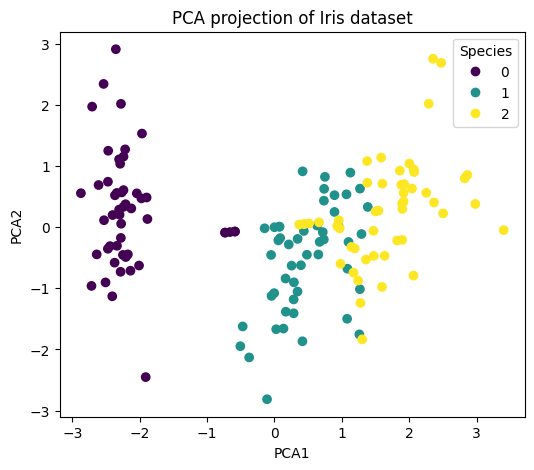

In [36]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df.drop(columns=["target"])

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# plot
plt.figure(figsize=(6,5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["target"], cmap="viridis")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA projection of Iris dataset")
plt.legend(*scatter.legend_elements(), title="Species")
plt.show()

#### 6. Interpretation

PCA1 separates three species fairly well, especially 0 from 1 and 2. PCA2 reveals finer structure between 1 and 2 further. 